#Data loader

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROCESSED = '/content/drive/MyDrive/Yelp JSON/yelp_dataset/data/processed/'

K_LIST = [4,5, 10, 20]
MIN_USER_CITIES = 3        # user must have reviewed at least 3 cities
MIN_CITY_INTERACTIONS = 5  # city must have at least 5 user interactions

In [ ]:
city_feat_pca = pd.read_parquet('/content/drive/MyDrive/Yelp JSON/yelp_dataset/data/processed/personality/city_features_pca_new.parquet')

In [ ]:
business = pd.read_parquet('/content/drive/MyDrive/Yelp JSON/yelp_dataset/data/processed/business_clean.parquet')
interact = pd.read_parquet('/content/drive/MyDrive/Yelp JSON/yelp_dataset/data/processed/review_interactions.parquet')
city_features = pd.read_parquet('/content/drive/MyDrive/Yelp JSON/yelp_dataset/data/processed/city_features_new.parquet')

print('business:', business.shape)
print('interact:', interact.shape)
print('city_features:', city_features.shape)

print('\ninteract columns:')
print(interact.columns.tolist())

print('\nbusiness columns:')
print(business.columns.tolist()[:30])

business: (150346, 58)
interact: (6990280, 3)
city_features: (1416, 75)

interact columns:
['user_id', 'business_id', 'stars']

business columns:
['business_id', 'name', 'city', 'state', 'latitude', 'longitude', 'stars', 'review_count', 'is_open', 'categories_list', 'primary_category', 'n_categories', 'attr__ByAppointmentOnly', 'attr__BusinessAcceptsCreditCards', 'attr__BikeParking', 'attr__RestaurantsPriceRange2', 'attr__RestaurantsTakeOut', 'attr__RestaurantsDelivery', 'attr__Caters', 'attr__WiFi', 'attr__BusinessParking__garage', 'attr__BusinessParking__street', 'attr__BusinessParking__validated', 'attr__BusinessParking__lot', 'attr__BusinessParking__valet', 'attr__WheelchairAccessible', 'attr__OutdoorSeating', 'attr__HasTV', 'attr__RestaurantsReservations', 'attr__Alcohol']


In [ ]:
import re

def canonical_city(city):
    if pd.isna(city):
        return city

    city = str(city).strip().lower()

    # remove punctuation
    city = re.sub(r'[^a-z0-9\s]', '', city)

    # collapse multiple spaces
    city = re.sub(r'\s+', ' ', city)

    return city

In [ ]:
business['city_clean'] = business['city'].apply(canonical_city)

In [ ]:
city_features['city_clean'] = (
    city_features['city']
    .apply(canonical_city)
)

In [ ]:
city_feat_pca['city_clean'] = (
    city_feat_pca['city']
    .apply(canonical_city)
)

In [ ]:
MIN_BUSINESSES = 70
MAX_BUSINESSES = 1043

# Filter cities by business count range
mask = (
    (city_features['n_businesses'] >= MIN_BUSINESSES) &
    (city_features['n_businesses'] <= MAX_BUSINESSES)
)

# Apply filtering
cities_filtered = city_feat_pca[mask].copy()
cities_orig_filtered = city_features[mask].copy()

# Reset index to avoid misalignment
cities_filtered = cities_filtered.reset_index(drop=True)
cities_orig_filtered = cities_orig_filtered.reset_index(drop=True)

# Extract city names
city_names = cities_orig_filtered['city_clean']

# Extract PCA features for clustering
pc_columns = [
    c for c in city_feat_pca.columns
    if c.startswith('PC')
]
X = cities_filtered[pc_columns].values

# Reporting
original_n = city_feat_pca['city_clean'].nunique()
filtered_n = len(cities_filtered)
removed_n = original_n - filtered_n

print(f'Original cities: {original_n}')
print(f'After filtering ({MIN_BUSINESSES} <= n_businesses <= {MAX_BUSINESSES}): {filtered_n}')
print(f'Removed: {removed_n} cities ({removed_n/original_n:.1%})')

print('\nBusiness count statistics after filtering:')
print(cities_orig_filtered['n_businesses'].describe())

print(f'\nSamples (city_names length): {len(city_names)}')
print(f'Clustering input shape (X): {X.shape}')

print('\nSample city names:')
print(city_names[:5].tolist())

Original cities: 1188
After filtering (70 <= n_businesses <= 1043): 219
Removed: 969 cities (81.6%)

Business count statistics after filtering:
count     219.000000
mean      237.027397
std       187.427146
min        70.000000
25%       111.500000
50%       170.000000
75%       292.000000
max      1043.000000
Name: n_businesses, dtype: float64

Samples (city_names length): 219
Clustering input shape (X): (219, 28)

Sample city names:
['abington', 'alton', 'ambler', 'antioch', 'apollo beach']


In [ ]:
city_feat_pca['city_clean'].nunique()

1188

In [ ]:
cities_filtered['city_clean'].nunique()

214

In [ ]:
# Aggregate duplicated canonical cities
cities_filtered = (
    cities_filtered
    .groupby('city_clean', as_index=False)[pc_columns]
    .mean()
)

In [ ]:
cities_filtered['city_clean'].duplicated().sum()

np.int64(0)

Baseline system: popularity-based city ranking


Stronger system: Hybrid recommendation model combining collaborative filtering (SVD), popularity signals, and content similarity derived from PCA city embeddings.

#Matrix

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import euclidean_distances

SEMANTIC_K = 4

kmeans = KMeans(
    n_clusters=SEMANTIC_K,
    random_state=42
)

cities_filtered['cluster'] = kmeans.fit_predict(
    cities_filtered[pc_columns]
)
centroid_dists = euclidean_distances(kmeans.cluster_centers_)
np.fill_diagonal(centroid_dists, np.inf)

cluster_neighbors = centroid_dists.argmin(axis=1)

In [ ]:
valid_city_set = set(cities_filtered['city_clean'])

user-city interaction table

one row = user-city preference signal.

In [ ]:
required_cols = {'user_id', 'business_id', 'stars'}
missing = required_cols - set(interact.columns)
if missing:
    raise ValueError(f'Missing columns in review_interactions.parquet: {missing}')

interact_city = interact.merge(
        business[['business_id', 'city_clean']],
        on='business_id',
        how='left'
    )
interact_city = interact_city[
    interact_city['city_clean'].isin(valid_city_set)
].copy()

interact_city = interact_city.dropna(subset=['user_id', 'city_clean', 'stars']).copy()

interact_city['stars'] = pd.to_numeric(interact_city['stars'], errors='coerce')
interact_city = interact_city.dropna(subset=['stars'])
print("Interact city shape:", interact_city.shape)

# Aggregate multiple reviews from the same user in the same city
user_city = (
    interact_city
    .groupby(['user_id', 'city_clean'])
    .agg(
        rating=('stars', 'mean'),
        n_reviews=('stars', 'size')
    )
    .reset_index()
)
# Keep only meaningful city visits
user_city = user_city[
    user_city['n_reviews'] >= 3
].copy()

print('Raw user_city:', user_city.shape)
display(user_city.head())

Interact city shape: (1956340, 4)
Raw user_city: (122706, 4)


,user_id,city_clean,rating,n_reviews
3,---2PmXbF47D870stH1jqA,new port richey,5.000000,7
51,--8Y8seruJEgwgwznJGyZA,goleta,3.000000,3
55,--8r3pNaZiG1fN8LCHuL_g,wesley chapel,3.000000,8
57,--9jUPPYMRSnJKlOskyyDA,kirkwood,2.333333,3
60,--Al1VYjHegnOfTVotCHFw,clayton,3.000000,6


In [ ]:
user_city['city_clean'].nunique()

214

In [ ]:
interact_city['city_clean'].nunique()

214

In [ ]:
#Filter sparse users and cities to improve the evaluation because users need history for train/test.
user_counts = user_city.groupby('user_id')['city_clean'].nunique()
valid_users = user_counts[user_counts >= MIN_USER_CITIES].index

city_counts = user_city.groupby('city_clean')['user_id'].nunique()
valid_cities = city_counts[city_counts >= MIN_CITY_INTERACTIONS].index

user_city_f = user_city[
    user_city['user_id'].isin(valid_users) &
    user_city['city_clean'].isin(valid_cities)
].copy()

print('Filtered user_city:', user_city_f.shape)
print('Users:', user_city_f['user_id'].nunique())
print('Cities:', user_city_f['city_clean'].nunique())

display(user_city_f.head())

Filtered user_city: (37377, 4)
Users: 7991
Cities: 213


,user_id,city_clean,rating,n_reviews
182,--_r6E98SNIrGU7weyNxbw,exton,3.200000,5
184,--_r6E98SNIrGU7weyNxbw,king of prussia,4.111111,9
186,--_r6E98SNIrGU7weyNxbw,malvern,3.750000,4
189,--_r6E98SNIrGU7weyNxbw,phoenixville,4.000000,3
192,--_r6E98SNIrGU7weyNxbw,west chester,3.923077,26


Train-test split by user

For each user, keep one liked city as test.
Train contains the rest of the user's city interactions.

Positive/liked city definition:
rating >= user's own mean rating.
This adapts the threshold to each user's rating behavior.

In [ ]:
def split_leave_one_out(df, random_state=42):
    rng = np.random.default_rng(random_state)
    train_rows = []
    test_rows = []

    for user, g in df.groupby('user_id'):
        g = g.copy()
        user_mean = g['rating'].mean()
        positives = g[g['rating'] >= user_mean]

        if len(positives) == 0 or len(g) < 2:
            continue

        test_idx = rng.choice(positives.index.values, size=1)[0]
        test_rows.append(g.loc[[test_idx]])
        train_rows.append(g.drop(index=test_idx))

    train = pd.concat(train_rows, ignore_index=True)
    test = pd.concat(test_rows, ignore_index=True)
    return train, test

train_uc, test_uc = split_leave_one_out(user_city_f, 42)

print('Train:', train_uc.shape)
print('Test:', test_uc.shape)
print('Train users:', train_uc['user_id'].nunique())
print('Test users:', test_uc['user_id'].nunique())

display(test_uc.head())

Train: (29386, 4)
Test: (7991, 4)
Train users: 7991
Test users: 7991


,user_id,city_clean,rating,n_reviews
0,--_r6E98SNIrGU7weyNxbw,king of prussia,4.111111,9
1,-1C-Lu0NTlYi4XB82ntKtg,university city,4.000000,3
2,-1MF2tosrw2WcCxeVNk81Q,feastervilletrevose,5.000000,3
3,-1W0vSD9aJXnHL63xiEciw,souderton,4.666667,3
4,-3s52C4zL_DHRK0ULG6qtg,webster groves,3.583333,12


In [ ]:
from scipy.sparse import csr_matrix

user_ids = sorted(train_uc['user_id'].unique())
city_ids = sorted(train_uc['city_clean'].unique())

user_to_idx = {
    u:i for i,u in enumerate(user_ids)
}

city_to_idx_cf = {
    c:i for i,c in enumerate(city_ids)
}

idx_to_city_cf = {
    i:c for c,i in city_to_idx_cf.items()
}

rows = train_uc['user_id'].map(user_to_idx)
cols = train_uc['city_clean'].map(city_to_idx_cf)

R = csr_matrix(
    (
        train_uc['rating'],
        (rows, cols)
    ),
    shape=(
        len(user_ids),
        len(city_ids)
    )
)

print(R.shape)

(7991, 213)


reason we chose 40 n factors can be seen on next section

In [ ]:
from sklearn.decomposition import TruncatedSVD

N_FACTORS = 40

svd = TruncatedSVD(
    n_components=N_FACTORS,
    random_state=42
)

user_factors = svd.fit_transform(R)
item_factors = svd.components_.T

print(user_factors.shape)
print(item_factors.shape)

(7991, 40)
(213, 40)


In [ ]:
def cf_score(user_id, city):

    if user_id not in user_to_idx:
        return 0.0

    if city not in city_to_idx_cf:
        return 0.0

    uidx = user_to_idx[user_id]
    cidx = city_to_idx_cf[city]

    return np.dot(
        user_factors[uidx],
        item_factors[cidx]
    )

In [ ]:
all_cf_scores = []

sample_users = list(user_to_idx.keys())[:500]

for user in sample_users:

    uidx = user_to_idx[user]

    preds = item_factors @ user_factors[uidx]

    all_cf_scores.extend(preds)

cf_min = np.min(all_cf_scores)
cf_max = np.max(all_cf_scores)

print(cf_min, cf_max)

-1.2023526745054434 5.610295978365023


In [ ]:
city_cluster_map = dict(
    zip(
        cities_filtered['city_clean'],
        cities_filtered['cluster']
    )
)

In [ ]:
user_city_f['cluster'] = (
    user_city_f['city_clean']
    .map(city_cluster_map)
)

In [ ]:
user_top_clusters = {}

for user_id, g in train_uc.groupby('user_id'):

    clusters = (
        g['city_clean']
        .map(city_cluster_map)
        .dropna()
    )

    if len(clusters) == 0:
        continue

    cluster_counts = (
        clusters
        .value_counts()
    )

    top_clusters = (
        cluster_counts
        .head(4)
        .index
        .tolist()
    )

    user_top_clusters[user_id] = top_clusters

In [ ]:
train_pairs = set(
    zip(train_uc['user_id'], train_uc['city_clean'])
)

test_pairs = set(
    zip(test_uc['user_id'], test_uc['city_clean'])
)

overlap = train_pairs & test_pairs

print('Overlap:', len(overlap))

Overlap: 0


Candidate-pool definition

Candidate pool for each user:

all cities in the filtered catalog EXCEPT cities already seen in train.
This simulates recommending new cities to the user.

We experimented using a filtered function of candidates but as mention later this wasnt the best approach:


def get_candidates(user_id, return_penalty=False):

    if user_id not in user_top_clusters:
        return [] if not return_penalty else ({}, [])

    target_clusters = user_top_clusters[user_id]
    seen = train_seen.get(user_id, set())

    candidate_penalty = {}

    # clusters principales
    main_cities = cities_filtered[
        cities_filtered['cluster'].isin(target_clusters)
    ]['city_clean'].tolist()

    for c in main_cities:
        if c not in seen:
            candidate_penalty[c] = 1.0

    # si solo tiene 1 cluster, agregar vecino penalizado
    if len(target_clusters) == 1:
        main_cluster = target_clusters[0]
        neighbor = cluster_neighbors[main_cluster]

        neighbor_cities = cities_filtered[
            cities_filtered['cluster'] == neighbor
        ]['city_clean'].tolist()

        for c in neighbor_cities:
            if c not in seen and c not in candidate_penalty:
                candidate_penalty[c] = 0.85

    candidates = list(candidate_penalty.keys())

    if return_penalty:
        return candidate_penalty, candidates

    return candidates

In [ ]:
all_cities = sorted(user_city_f['city_clean'].unique())

# Recreate content_city_to_idx to resolve NameError
city_content = cities_filtered.copy()
city_content = city_content[
    city_content['city_clean'].isin(all_cities)
].copy()
content_city_list = city_content['city_clean'].tolist()
content_city_to_idx = {
    c: i for i, c in enumerate(content_city_list)
}

train_seen = (
    train_uc
    .groupby('user_id')['city_clean']
    .apply(set)
    .to_dict()
)

test_truth = (
    test_uc
    .groupby('user_id')['city_clean']
    .apply(set)
    .to_dict()
)

def get_candidates_all(user_id):

    seen = set(
        train_uc.loc[
            train_uc['user_id'] == user_id,
            'city_clean'
        ]
    )

    candidates = [
        c for c in content_city_to_idx
        if c not in seen
    ]

    return {c:1.0 for c in candidates}, candidates

example_user = test_uc['user_id'].iloc[0]
print('Example user:', example_user)
print('Seen cities:', len(train_seen[example_user]))
print('Candidate cities:', len(get_candidates_all(example_user)))
print('Test city:', test_truth[example_user])

Example user: --_r6E98SNIrGU7weyNxbw
Seen cities: 4
Candidate cities: 2
Test city: {'king of prussia'}


In [ ]:
train_seen[example_user]

{'exton', 'malvern', 'phoenixville', 'west chester'}

Baseline system: popularity-based ranking

Popularity score uses only TRAIN data to avoid leakage.
It combines:
- number of users who reviewed the city
- average rating

In [ ]:
city_popularity = (
    train_uc
    .groupby('city_clean')
    .agg(
        train_users=('user_id', 'nunique'),
        train_reviews=('n_reviews', 'sum'),
        train_avg_rating=('rating', 'mean')
    )
    .reset_index()
)

# Normalize components
city_popularity['pop_users_z'] = (
    city_popularity['train_users'] - city_popularity['train_users'].mean()
) / (city_popularity['train_users'].std() + 1e-9)

city_popularity['rating_z'] = (
    city_popularity['train_avg_rating'] - city_popularity['train_avg_rating'].mean()
) / (city_popularity['train_avg_rating'].std() + 1e-9)

city_popularity['baseline_score'] = (
    0.70 * city_popularity['pop_users_z'] +
    0.30 * city_popularity['rating_z']
)

baseline_scores = dict(zip(city_popularity['city_clean'], city_popularity['baseline_score']))

def recommend_popularity(user_id, k=10):
    candidates = get_candidates(user_id)
    ranked = sorted(
        candidates,
        key=lambda c: baseline_scores.get(c, -999),
        reverse=True
    )
    return ranked[:k]

display(city_popularity.sort_values('baseline_score', ascending=False).head(10))

,city_clean,train_users,train_reviews,train_avg_rating,pop_users_z,rating_z,baseline_score
181,st louis,832,13088,3.814166,5.314399,1.053961,4.036267
183,st petersburg,766,10516,3.851996,4.809022,1.251928,3.741894
101,king of prussia,817,6602,3.444505,5.199540,-0.880525,3.375521
34,cherry hill,697,7638,3.605876,4.280674,-0.036049,2.985657
52,dunedin,409,3980,3.933405,2.075394,1.677954,1.956162
109,largo,427,4231,3.776045,2.213224,0.854466,1.805597
19,brandon,454,6675,3.659711,2.419969,0.245678,1.767682
151,palm harbor,400,4114,3.750879,2.006479,0.722769,1.621366
37,clayton,342,2405,3.853841,1.562361,1.261583,1.472127
186,tarpon springs,333,2405,3.802347,1.493446,0.992109,1.343045


Cluster-filtered semantic ranking

Data alignment:
- User preferences are inferred from aggregated Yelp business reviews at the city level.
- City representations come from PCA latent embeddings generated from enriched urban descriptors.
- Cluster-based information derived from KMeans (K=4) is incorporated as contextual information and popularity signals.
- Candidate cities are generated from the full city catalog, excluding cities already observed in the user's training history.

For each user:
1. Build a user profile as the weighted average of city feature vectors from the user's TRAIN cities.
2. Compare candidate cities to that user profile using cosine similarity.
3. Combine content similarity with CF prediction.


In [ ]:
city_content = cities_filtered.copy()

city_content = city_content[
    city_content['city_clean'].isin(all_cities)
].copy()

pc_columns = [c for c in city_content.columns if c.startswith('PC')]

X_content_raw = city_content[pc_columns].values

pc_weights = city_content[pc_columns].std().values
pc_weights = np.where(pc_weights == 0, 1e-9, pc_weights)

X_content = X_content_raw / pc_weights # normalize

content_city_list = city_content['city_clean'].tolist()

content_city_to_idx = {
    c: i for i, c in enumerate(content_city_list)
}

print('Cities with PCA embeddings:', len(content_city_list))
print('Latent PCA dimensions:', X_content.shape[1]) #matrix city × 28 PCs normalized

Cities with PCA embeddings: 213
Latent PCA dimensions: 28


In [ ]:
user_content_profiles = {}

for user_id, hist in train_uc.groupby('user_id'):

    hist = hist[
        hist['city_clean'].isin(content_city_to_idx.keys())
    ]

    if hist.empty:
        continue

    weights = (
        hist['rating'].values
        * np.log1p(hist['n_reviews'].values)
    )

    weights = weights / (weights.sum() + 1e-9)

    hist_vectors = np.vstack([
        X_content[content_city_to_idx[c]]
        for c in hist['city_clean'].values
    ])

    profile = np.average(
        hist_vectors,
        axis=0,
        weights=weights
    )

    user_content_profiles[user_id] = profile

The content-based component first builds a user profile as a weighted average of the PCA embeddings of previously visited cities. The weights are proportional to the user's rating and interaction frequency. Cosine similarity is then used to compare this profile against candidate city embeddings and generate a content-based relevance score.

In [ ]:
cluster_popularity = {}

for cluster_id, g in user_city_f.groupby('cluster'):

    stats = (
        g.groupby('city_clean')
        .agg(
            avg_rating=('rating', 'mean'),
            n_users=('user_id', 'nunique')
        )
    )

    stats['popularity_score'] = (
        stats['avg_rating']
        * np.log1p(stats['n_users'])
    )

    # normalize inside cluster
    stats['popularity_score'] = (
        stats['popularity_score']
        - stats['popularity_score'].min()
    ) / (
        stats['popularity_score'].max()
        - stats['popularity_score'].min()
        + 1e-9
    )

    cluster_popularity[cluster_id] = (
        stats['popularity_score']
        .to_dict()
    )

In [ ]:
def get_candidates(user_id):
    _, candidates_list = get_candidates_all(user_id)
    return candidates_list

def recommend_hybrid(
    user_id,
    k=10,
    w_content=0.05,
    w_pop=0.10,
    w_cf=0.85
):

    candidate_penalty, candidates = get_candidates_all(
        user_id
    )

    if user_id not in user_content_profiles:
        return []

    candidates = [
        c for c in candidates
        if c in content_city_to_idx
    ]

    if not candidates:
        return []

    user_profile = user_content_profiles[user_id]

    candidate_idx = [
        content_city_to_idx[c]
        for c in candidates
    ]

    candidate_matrix = X_content[candidate_idx]
    #cosine
    content_scores = cosine_similarity(
        user_profile.reshape(1, -1),
        candidate_matrix
    ).flatten()

    scores = []

    for city, content_s in zip(candidates, content_scores):

        cluster_id = city_cluster_map.get(city)
        #popularidad calculada dentro del cluster
        pop_s = (
            cluster_popularity #already normalized
            .get(cluster_id, {})
            .get(city, 0)
        )

        cf_s = cf_score(user_id, city)

        cf_s = (
            cf_s - cf_min
        ) / (
            cf_max - cf_min + 1e-9
        )

        hybrid_s = (
            w_content * content_s +
            w_pop * pop_s +
            w_cf * cf_s
        )

        hybrid_s *= candidate_penalty.get(city, 1.0)

        scores.append((city, hybrid_s))

    scores.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return [c for c, _ in scores[:k]]

def recommend_semantic(user_id, k=10):
    return recommend_hybrid(
        user_id,
        k=k,
        w_content=0.05,
        w_pop=0.10,
        w_cf=0.85
    )


example_user = test_uc['user_id'].iloc[0]
print('Example user:', example_user)
print('Popularity:', recommend_popularity(example_user, 5))
print('Hybrid ranking:', recommend_hybrid(example_user, 5))
print('Ground truth:', test_truth[example_user])

Example user: --_r6E98SNIrGU7weyNxbw
Popularity: ['st louis', 'st petersburg', 'king of prussia', 'cherry hill', 'dunedin']
Hybrid ranking: ['downingtown', 'collegeville', 'royersford', 'paoli', 'pottstown']
Ground truth: {'king of prussia'}


In [ ]:
#reload drive collab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import joblib
import os

SAVE_PATH = '/content/drive/MyDrive/Yelp JSON/yelp_dataset/data/processed/w11/'

# ── 1. city_popularity ─────────────────
city_popularity.to_parquet(SAVE_PATH + 'w10_city_popularity.parquet', index=False)
print('✅ w10_city_popularity.parquet')

# ── 2. cities_filtered con clusters ─────────────────────────────
cities_filtered.to_parquet(SAVE_PATH + 'w10_cities_filtered.parquet', index=False)
print('✅ w10_cities_filtered.parquet')

# ── 3. user_city_f — interacciones filtradas ─────────────────────
user_city_f.to_parquet(SAVE_PATH + 'w10_user_city_f.parquet', index=False)
print('✅ w10_user_city_f.parquet')

# ── 4. train_uc y test_uc — splits ───────────────────────────────
train_uc.to_parquet(SAVE_PATH + 'w10_train_uc.parquet', index=False)
test_uc.to_parquet(SAVE_PATH + 'w10_test_uc.parquet', index=False)
print('✅ w10_train_uc.parquet')
print('✅ w10_test_uc.parquet')

# ── 5. SVD factors — para reconstruir cf_score ───────────────────
np.save(SAVE_PATH + 'w10_user_factors.npy', user_factors)
np.save(SAVE_PATH + 'w10_item_factors.npy', item_factors)
print('✅ w10_user_factors.npy')
print('✅ w10_item_factors.npy')

# ── 6. Índices user/city para el SVD ─────────────────────────────
pd.DataFrame({'user_id': list(user_to_idx.keys()),
              'idx':     list(user_to_idx.values())})\
  .to_parquet(SAVE_PATH + 'w10_user_to_idx.parquet', index=False)

pd.DataFrame({'city_clean': list(city_to_idx_cf.keys()),
              'idx':        list(city_to_idx_cf.values())})\
  .to_parquet(SAVE_PATH + 'w10_city_to_idx_cf.parquet', index=False)
print('✅ w10_user_to_idx.parquet')
print('✅ w10_city_to_idx_cf.parquet')

# ── 7. X_content y content_city_list ─────────────────────────────
np.save(SAVE_PATH + 'w10_X_content.npy', X_content)
pd.DataFrame({'city_clean': content_city_list})\
  .to_parquet(SAVE_PATH + 'w10_content_city_list.parquet', index=False)
print('✅ w10_X_content.npy')
print('✅ w10_content_city_list.parquet')

# ── 8. cf_min y cf_max para normalización ────────────────────────
pd.DataFrame({'cf_min': [cf_min], 'cf_max': [cf_max]})\
  .to_parquet(SAVE_PATH + 'w10_cf_bounds.parquet', index=False)
print('w10_cf_bounds.parquet')


✅ w10_city_popularity.parquet
✅ w10_cities_filtered.parquet
✅ w10_user_city_f.parquet
✅ w10_train_uc.parquet
✅ w10_test_uc.parquet
✅ w10_user_factors.npy
✅ w10_item_factors.npy
✅ w10_user_to_idx.parquet
✅ w10_city_to_idx_cf.parquet
✅ w10_X_content.npy
✅ w10_content_city_list.parquet
w10_cf_bounds.parquet


In [ ]:
city_popularity.to_csv('city_popularity.csv', index=False)
#city_cluster_map = pd.DataFrame(list(city_cluster_map.items()), columns=['city_clean', 'cluster'])
#city_cluster_map.to_csv('city_cluster_map.csv', index=False)

In [ ]:
# evaluation metrics
def precision_at_k(recs, truth, k):
    recs_k = recs[:k]
    return len(set(recs_k) & truth) / k

def recall_at_k(recs, truth, k):
    if len(truth) == 0:
        return 0.0
    recs_k = recs[:k]
    return len(set(recs_k) & truth) / len(truth)

def hit_rate_at_k(recs, truth, k):
    recs_k = recs[:k]
    return 1.0 if len(set(recs_k) & truth) > 0 else 0.0

def ndcg_at_k(recs, truth, k):
    recs_k = recs[:k]
    dcg = 0.0
    for i, item in enumerate(recs_k):
        if item in truth:
            dcg += 1.0 / np.log2(i + 2)
    ideal_hits = min(len(truth), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))
    return dcg / idcg if idcg > 0 else 0.0

def average_precision_at_k(recs, truth, k):
    recs_k = recs[:k]
    hits = 0
    score = 0.0
    for i, item in enumerate(recs_k, start=1):
        if item in truth:
            hits += 1
            score += hits / i
    return score / min(len(truth), k) if truth else 0.0

def evaluate_model(name, recommender_func, users_eval, k_list=K_LIST):

    rows = []
    all_recs = {}

    for user_id in users_eval:
        all_recs[user_id] = recommender_func(
            user_id,
            k=max(k_list)
        )

    # PRECOMPUTAR UNA VEZ
    for k in k_list:

        metrics = []

        for user_id in users_eval:

            truth = test_truth.get(user_id, set())

            if not truth:
                continue

            recs = all_recs[user_id]

            metrics.append({
                'precision': precision_at_k(recs, truth, k),
                'recall': recall_at_k(recs, truth, k),
                'hit_rate': hit_rate_at_k(recs, truth, k),
                'ndcg': ndcg_at_k(recs, truth, k),
                'map': average_precision_at_k(recs, truth, k)
            })

        m = pd.DataFrame(metrics).mean().to_dict()

        rows.append({
            'model': name,
            'k': k,
            'precision@k': m['precision'],
            'recall@k': m['recall'],
            'hit_rate@k': m['hit_rate'],
            'ndcg@k': m['ndcg'],
            'map@k': m['map'],
            'n_users_eval': len(metrics)
        })

    return pd.DataFrame(rows)

rng = np.random.default_rng(42)

users_eval = sorted(
    test_uc['user_id'].unique()
)
eval_pop = evaluate_model('Baseline: Popularity', recommend_popularity, users_eval)
display(eval_pop)

,model,k,precision@k,recall@k,hit_rate@k,ndcg@k,map@k,n_users_eval
0,Baseline: Popularity,4,0.032067,0.128269,0.128269,0.085598,0.071414,7991
1,Baseline: Popularity,5,0.030184,0.150920,0.150920,0.094360,0.075944,7991
2,Baseline: Popularity,10,0.022563,0.225629,0.225629,0.118181,0.085573,7991
3,Baseline: Popularity,20,0.016850,0.337004,0.337004,0.145959,0.092997,7991


In [ ]:
eval_cf_hybrid = evaluate_model(
    'Content+Popularity+CF',
    recommend_semantic,
    users_eval
)

display(eval_cf_hybrid)

,model,k,precision@k,recall@k,hit_rate@k,ndcg@k,map@k,n_users_eval
0,Content+Popularity+CF,4,0.130178,0.520711,0.520711,0.404069,0.364681,7991
1,Content+Popularity+CF,5,0.112076,0.560380,0.560380,0.419415,0.372615,7991
2,Content+Popularity+CF,10,0.069315,0.693155,0.693155,0.462614,0.390597,7991
3,Content+Popularity+CF,20,0.039551,0.791015,0.791015,0.487615,0.397595,7991


In [ ]:
eval_report = pd.concat(
    [eval_pop, eval_cf_hybrid],
    ignore_index=True
)

weight configurations for best results in the hybrid system

In [ ]:
weight_configs = [
    (0.10, 0.20, 0.70),
    (0.20, 0.10, 0.70),
    (0.15, 0.10, 0.75),
    (0.10, 0.10, 0.80),
    (0.20, 0.05, 0.75),
    (0.15, 0.05, 0.80),
    (0.05, 0.10, 0.85),
    (0.10, 0.05, 0.85),
    (0.05, 0.05, 0.90)
]

weight_results = []

for wc, wp, wcf in weight_configs:

    recommender = lambda user_id, k, wc=wc, wp=wp, wcf=wcf: (
        recommend_hybrid(
            user_id,
            k=k,
            w_content=wc,
            w_pop=wp,
            w_cf=wcf
        )
    )

    eval_df = evaluate_model(
        f'C={wc:.2f} P={wp:.2f} CF={wcf:.2f}',
        recommender,
        users_eval
    )

    weight_results.append(eval_df)

weight_report = pd.concat(
    weight_results,
    ignore_index=True
)

display(weight_report)

,model,k,precision@k,recall@k,hit_rate@k,ndcg@k,map@k,n_users_eval
0,C=0.10 P=0.20 CF=0.70,4,0.123827,0.495307,0.495307,0.385905,0.348934,7991
1,C=0.10 P=0.20 CF=0.70,5,0.105944,0.529721,0.529721,0.399218,0.355817,7991
2,C=0.10 P=0.20 CF=0.70,10,0.065086,0.650857,0.650857,0.438380,0.371973,7991
3,C=0.10 P=0.20 CF=0.70,20,0.037236,0.744713,0.744713,0.462113,0.378486,7991
4,C=0.20 P=0.10 CF=0.70,4,0.121355,0.485421,0.485421,0.379479,0.343699,7991
5,C=0.20 P=0.10 CF=0.70,5,0.105794,0.528970,0.528970,0.396327,0.352409,7991
6,C=0.20 P=0.10 CF=0.70,10,0.064322,0.643224,0.643224,0.433424,0.367807,7991
7,C=0.20 P=0.10 CF=0.70,20,0.036723,0.734451,0.734451,0.456517,0.374162,7991
8,C=0.15 P=0.10 CF=0.75,4,0.126517,0.506069,0.506069,0.392970,0.354805,7991
9,C=0.15 P=0.10 CF=0.75,5,0.109423,0.547116,0.547116,0.408849,0.363015,7991


In [ ]:
best_weights = (
    weight_report[
        weight_report['k'] == 4
    ]
    .sort_values(
        'ndcg@k',
        ascending=False
    )
    .head(10)
)

display(best_weights)

,model,k,precision@k,recall@k,hit_rate@k,ndcg@k,map@k,n_users_eval
24,C=0.05 P=0.10 CF=0.85,4,0.130178,0.520711,0.520711,0.404069,0.364681,7991
32,C=0.05 P=0.05 CF=0.90,4,0.130053,0.520210,0.520210,0.403103,0.363586,7991
12,C=0.10 P=0.10 CF=0.80,4,0.129489,0.517958,0.517958,0.401782,0.362595,7991
28,C=0.10 P=0.05 CF=0.85,4,0.128989,0.515955,0.515955,0.399833,0.360635,7991
20,C=0.15 P=0.05 CF=0.80,4,0.126736,0.506945,0.506945,0.393819,0.355598,7991
8,C=0.15 P=0.10 CF=0.75,4,0.126517,0.506069,0.506069,0.392970,0.354805,7991
0,C=0.10 P=0.20 CF=0.70,4,0.123827,0.495307,0.495307,0.385905,0.348934,7991
16,C=0.20 P=0.05 CF=0.75,4,0.123201,0.492804,0.492804,0.384553,0.348006,7991
4,C=0.20 P=0.10 CF=0.70,4,0.121355,0.485421,0.485421,0.379479,0.343699,7991


The best-performing one is clearly where 85% represents collaborative filtering, while content-based and popularity signals contribute complementary information.

In [ ]:
best_weights = (
    weight_report[
        weight_report['k'] == 4
    ]
    .sort_values(
        'map@k',
        ascending=False
    )
    .head(10)
)

display(best_weights)

,model,k,precision@k,recall@k,hit_rate@k,ndcg@k,map@k,n_users_eval
24,C=0.05 P=0.10 CF=0.85,4,0.130178,0.520711,0.520711,0.404069,0.364681,7991
32,C=0.05 P=0.05 CF=0.90,4,0.130053,0.520210,0.520210,0.403103,0.363586,7991
12,C=0.10 P=0.10 CF=0.80,4,0.129489,0.517958,0.517958,0.401782,0.362595,7991
28,C=0.10 P=0.05 CF=0.85,4,0.128989,0.515955,0.515955,0.399833,0.360635,7991
20,C=0.15 P=0.05 CF=0.80,4,0.126736,0.506945,0.506945,0.393819,0.355598,7991
8,C=0.15 P=0.10 CF=0.75,4,0.126517,0.506069,0.506069,0.392970,0.354805,7991
0,C=0.10 P=0.20 CF=0.70,4,0.123827,0.495307,0.495307,0.385905,0.348934,7991
16,C=0.20 P=0.05 CF=0.75,4,0.123201,0.492804,0.492804,0.384553,0.348006,7991
4,C=0.20 P=0.10 CF=0.70,4,0.121355,0.485421,0.485421,0.379479,0.343699,7991


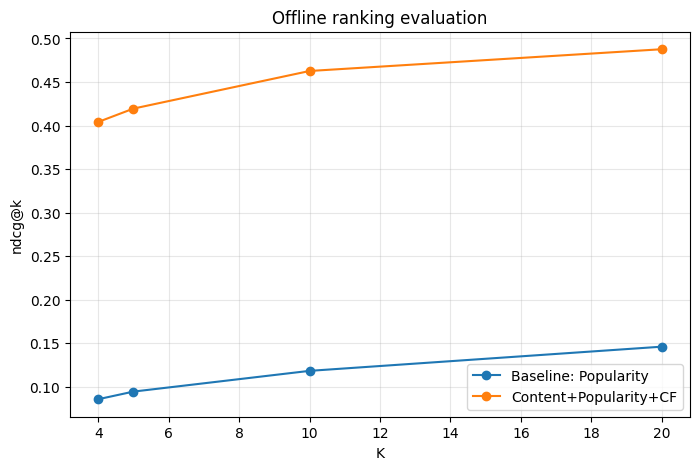

In [ ]:
# Plot model comparison
metric_to_plot = 'ndcg@k'

plt.figure(figsize=(8, 5))
for model_name, g in eval_report.groupby('model'):
    plt.plot(g['k'], g[metric_to_plot], marker='o', label=model_name)

plt.xlabel('K')
plt.ylabel(metric_to_plot)
plt.title('Offline ranking evaluation')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Error analysis
# Strong case = test city appears in top 10.
# Failure case = test city does not appear in top 20.

def rank_of_truth(user_id, recommender_func, max_k=50):
    truth = test_truth.get(user_id, set())
    recs = recommender_func(user_id, k=max_k)

    ranks = []
    for t in truth:
        if t in recs:
            ranks.append(recs.index(t) + 1)
        else:
            ranks.append(None)

    best_rank = min([r for r in ranks if r is not None], default=None)
    return best_rank, list(truth), recs

analysis_rows = []
for user_id in users_eval:
    best_rank, truth_city, recs = rank_of_truth(
        user_id,
        recommend_semantic,
        max_k=50
    )
    analysis_rows.append({
        'user_id': user_id,
        'test_city': truth_city[0] if truth_city else None,
        'rank_of_test_city': best_rank,
        'top_10_recommendations': recs[:10],
        'status': 'strong_case' if best_rank is not None and best_rank <= 10
                  else ('failure_case' if best_rank is None or best_rank > 20 else 'medium_case')
    })

error_df = pd.DataFrame(analysis_rows)

print('Error analysis summary:')
display(error_df['status'].value_counts().reset_index().rename(columns={'index':'status', 'status':'count'}))

print('\nStrong cases:')
display(error_df[error_df['status'] == 'strong_case'].head(5))

print('\nFailure cases:')
display(error_df[error_df['status'] == 'failure_case'].head(5))

Error analysis summary:


,count,count
0,strong_case,5539
1,failure_case,1670
2,medium_case,782



Strong cases:


,user_id,test_city,rank_of_test_city,top_10_recommendations,status
1,-1C-Lu0NTlYi4XB82ntKtg,university city,1.0,"[university city, kirkwood, webster groves, br...",strong_case
4,-3s52C4zL_DHRK0ULG6qtg,webster groves,2.0,"[university city, webster groves, richmond hei...",strong_case
5,-4mjLXqAoAtQjqDFo9q9WQ,maryland heights,1.0,"[maryland heights, ballwin, florissant, bridge...",strong_case
6,-4vkTh2rImD8c0-30h2uvw,maplewood,1.0,"[maplewood, webster groves, university city, d...",strong_case
8,-5G4J4zfduWQSgyepUbCog,florissant,6.0,"[st charles, saint charles, chesterfield, univ...",strong_case



Failure cases:


,user_id,test_city,rank_of_test_city,top_10_recommendations,status
0,--_r6E98SNIrGU7weyNxbw,king of prussia,NaN,"[downingtown, collegeville, royersford, paoli,...",failure_case
2,-1MF2tosrw2WcCxeVNk81Q,feastervilletrevose,NaN,"[moorestown, maple shade, langhorne, marlton, ...",failure_case
3,-1W0vSD9aJXnHL63xiEciw,souderton,44.0,"[ambler, blue bell, cherry hill, doylestown, p...",failure_case
21,-FH9K-xkwdE25gH8lGGQ3w,chesterfield,NaN,"[belleville, ofallon, fairview heights, st pet...",failure_case
25,-GDdBOfhrxn7lAGblLSoqA,meridian,48.0,"[palm harbor, largo, lutz, brandon, st petersb...",failure_case


Although the hybrid system does not always retrieve the exact target city, it frequently recommends cities with similar urban profiles/business characteristics. This indicates that city-content features contribute to recommendation coherence, although collaborative filtering remains the main source of predictive power.

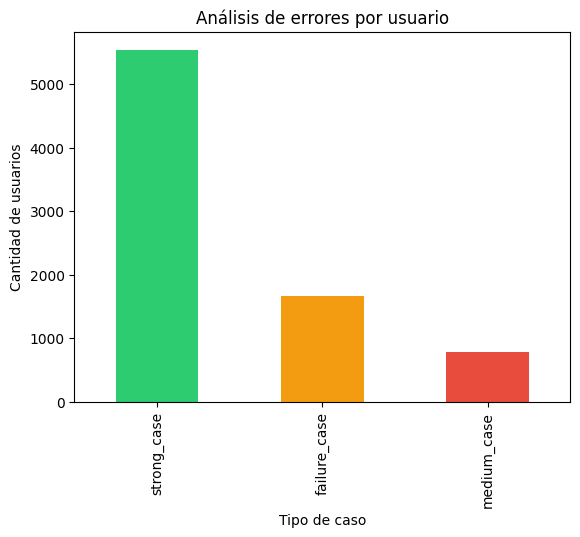

In [ ]:
# Gráfico 2: Strong / Medium / Failure
error_df['status'].value_counts().plot(kind='bar', color=['#2ecc71', '#f39c12', '#e74c3c'])
plt.title('Análisis de errores por usuario')
plt.xlabel('Tipo de caso')
plt.ylabel('Cantidad de usuarios')
plt.show()

In [ ]:
#  Explain strong and failure cases with user history

def explain_user_case(user_id, recommender_func=recommend_semantic, k=10):
    history = train_uc[train_uc['user_id'] == user_id].sort_values('rating', ascending=False)
    truth = list(test_truth.get(user_id, []))
    recs = recommender_func(user_id, k=k)

    print('='*80)
    print('USER:', user_id)
    print('\nTRAIN HISTORY: cities already visited/rated')
    display(history[['city_clean', 'rating', 'n_reviews']].head(10))

    print('\nTEST CITY / ground truth:')
    print(truth)

    print(f'\nTOP {k} RECOMMENDATIONS:')
    for i, city in enumerate(recs, start=1):
        marker = '<-- HIT' if city in truth else ''
        print(f'{i:02d}. {city} {marker}')

# Show one strong and one failure case if available
strong_users = error_df[error_df['status'] == 'strong_case']['user_id'].head(1).tolist()
failure_users = error_df[error_df['status'] == 'failure_case']['user_id'].head(1).tolist()

if strong_users:
    print('\nSTRONG CASE EXPLANATION')
    explain_user_case(strong_users[0])

if failure_users:
    print('\nFAILURE CASE EXPLANATION')
    explain_user_case(failure_users[0])


STRONG CASE EXPLANATION
USER: -1C-Lu0NTlYi4XB82ntKtg

TRAIN HISTORY: cities already visited/rated


,city_clean,rating,n_reviews
5,st louis,4.200000,5
4,maplewood,3.444444,9



TEST CITY / ground truth:
['university city']

TOP 10 RECOMMENDATIONS:
01. university city <-- HIT
02. kirkwood 
03. webster groves 
04. brentwood 
05. st petersburg 
06. collingswood 
07. palm harbor 
08. wesley chapel 
09. clayton 
10. brandon 

FAILURE CASE EXPLANATION
USER: --_r6E98SNIrGU7weyNxbw

TRAIN HISTORY: cities already visited/rated


,city_clean,rating,n_reviews
2,phoenixville,4.000000,3
3,west chester,3.923077,26
1,malvern,3.750000,4
0,exton,3.200000,5



TEST CITY / ground truth:
['king of prussia']

TOP 10 RECOMMENDATIONS:
01. downingtown 
02. collegeville 
03. royersford 
04. paoli 
05. pottstown 
06. berwyn 
07. norristown 
08. kennett square 
09. glen mills 
10. wayne 


In [ ]:
best_k = 4
report_k4 = eval_report[eval_report['k'] == best_k].sort_values('ndcg@k', ascending=False)

print('WEEK 10 REPORT SUMMARY')
print('='*80)

print('\nModel architecture:')
print('\n1. City features are transformed into latent urban embeddings using PCA.')
print('\n2. User-city interactions are modeled through matrix factorization (Truncated SVD).')
print('\n3. User profiles are represented through weighted city-content vectors.')
print('\n4. Final recommendations are generated using a hybrid ranking function that combines:')
print('\n   - Collaborative Filtering (85%)')
print('\n   - Popularity (10%)')
print('\n   - Content Similarity (5%)')
display(report_k4)

print('\nError analysis:')
print('- Strong cases: users whose hidden test city appears in top 10.')
print('- Failure cases: users whose hidden test city is missing from top 20.')
print('- Failures may happen for sparse users, unpopular cities, noisy ratings, or cold-start cities with weak overlap.')

WEEK 10 REPORT SUMMARY

Project type:
- This project is mainly a recommendation and ranking system.
- It predicts a personalized score for each candidate city and ranks cities for each user.
- Segmentation/PCA features from previous weeks can feed the ranking as city content features.

Candidate-pool definition:
- For each user, candidate cities are all filtered cities not already seen in the user training history.
- The hidden test city is one liked city removed from the user history.

Baseline:
- Popularity-based ranking using train-only city popularity and average rating.

Protocol limitation:
Only users with at least 3 reviewed cities and meaningful city visit histories are evaluated.

Advanced systems:
- Semantic cluster-based ranking using PCA latent urban embeddings.
- Candidate cities are filtered using semantic KMeans clusters (K=4).
- Cities are ranked through cosine similarity against user semantic profiles.
- The system follows a segmentation-feeding-ranking recommendation 

,model,k,precision@k,recall@k,hit_rate@k,ndcg@k,map@k,n_users_eval
4,Content+Popularity+CF,4,0.130178,0.520711,0.520711,0.404069,0.364681,7991
0,Baseline: Popularity,4,0.032067,0.128269,0.128269,0.085598,0.071414,7991



Error analysis:
- Strong cases: users whose hidden test city appears in top 10.
- Failure cases: users whose hidden test city is missing from top 20.
- Failures may happen for sparse users, unpopular cities, noisy ratings, or cold-start cities with weak overlap.


deeper analysis to know if larger histories impacted on strong/failure cases:

In [ ]:
sample_users = rng.choice(
    users_eval,
    size=6000,
    replace=False
)

In [ ]:
train_city_counts = (
    train_uc.groupby('user_id')['city_clean']
            .nunique()
            .to_dict()
)

analysis_rows = []

for user_id in sample_users:

    truth = test_truth.get(user_id, set())

    if not truth:
        continue

    recs = recommend_hybrid(user_id, k=4)

    analysis_rows.append({
        "user_id": user_id,
        "n_train_cities": train_city_counts.get(user_id, 0),
        "hit": hit_rate_at_k(recs, truth, 4),
        "ndcg": ndcg_at_k(recs, truth, 4),
        "target_city": list(truth)[0]
    })

analysis_df = pd.DataFrame(analysis_rows)

In [ ]:
strong = analysis_df[
    analysis_df["hit"] == 1
]

failure = analysis_df[
    analysis_df["hit"] == 0
]

In [ ]:
strong["n_train_cities"].mean()

np.float64(3.672733077905492)

In [ ]:
failure["n_train_cities"].mean()

np.float64(3.6297071129707112)

In [ ]:
analysis_df["n_train_cities"].describe()

,n_train_cities
count,6000.000000
mean,3.652167
std,2.961864
min,2.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,51.000000


The evaluation population is dominated by users with relatively short travel histories. Among a sample of 6000 evaluated users, the median number of training cities was 3 and 75% of users had four or fewer cities in their profiles.

In [ ]:
analysis_df.groupby("n_train_cities")["hit"].agg(
    ["count","mean"]
).sort_index()

,count,mean
n_train_cities,,
2,2823,0.509387
3,1303,0.549501
4,639,0.527387
5,369,0.523035
6,255,0.513725
7,153,0.470588
8,109,0.550459
9,84,0.428571
10,65,0.507692


Recommendation success was observed across users with both short and long interaction histories. Although users with richer histories provide more preference information, the evaluation did not reveal a consistent relationship between history length and Hit Rate. This suggests that factors beyond interaction volume influence recommendation quality.

# Looking for better n_factors used in SVD

In [ ]:
factor_list = [35, 40, 45, 50,55,60,70]

factor_results = []

for n_factors in factor_list:

    print(f'\nTesting N_FACTORS = {n_factors}')

    svd = TruncatedSVD(
        n_components=n_factors,
        random_state=42
    )

    user_factors = svd.fit_transform(R)
    item_factors = svd.components_.T

    explained = svd.explained_variance_ratio_.sum()

    print(f'Explained variance: {explained:.4f}')

    # recalcular cf_min y cf_max
    all_cf_scores = []

    sample_users = list(user_to_idx.keys())[:500]

    for user in sample_users:

        uidx = user_to_idx[user]

        preds = item_factors @ user_factors[uidx]

        all_cf_scores.extend(preds)

    cf_min = np.min(all_cf_scores)
    cf_max = np.max(all_cf_scores)

    eval_df = evaluate_model(
        f'SVD_{n_factors}',
        lambda user_id, k:
            recommend_hybrid(
                user_id,
                k=k,
                w_content=0.05,
                w_pop=0.10,
                w_cf=0.85
            ),
        users_eval
    )

    eval_df['explained_var'] = explained

    factor_results.append(eval_df)


Testing N_FACTORS = 35
Explained variance: 0.5533

Testing N_FACTORS = 40
Explained variance: 0.5861

Testing N_FACTORS = 45
Explained variance: 0.6171

Testing N_FACTORS = 50
Explained variance: 0.6453

Testing N_FACTORS = 55
Explained variance: 0.6705

Testing N_FACTORS = 60
Explained variance: 0.6942

Testing N_FACTORS = 70
Explained variance: 0.7372


In [ ]:
factor_report = pd.concat(
    factor_results,
    ignore_index=True
)

display(factor_report)

,model,k,precision@k,recall@k,hit_rate@k,ndcg@k,map@k,n_users_eval,explained_var
0,SVD_35,4,0.127331,0.509323,0.509323,0.393709,0.354743,7991,0.553339
1,SVD_35,5,0.110975,0.554874,0.554874,0.411330,0.363853,7991,0.553339
2,SVD_35,10,0.068702,0.687023,0.687023,0.453934,0.381358,7991,0.553339
3,SVD_35,20,0.039657,0.793142,0.793142,0.481070,0.388968,7991,0.553339
4,SVD_40,4,0.130178,0.520711,0.520711,0.404069,0.364681,7991,0.586077
5,SVD_40,5,0.112076,0.560380,0.560380,0.419415,0.372615,7991,0.586077
6,SVD_40,10,0.069315,0.693155,0.693155,0.462614,0.390597,7991,0.586077
7,SVD_40,20,0.039551,0.791015,0.791015,0.487615,0.397595,7991,0.586077
8,SVD_45,4,0.127112,0.508447,0.508447,0.391808,0.352501,7991,0.617121
9,SVD_45,5,0.110675,0.553373,0.553373,0.409187,0.361486,7991,0.617121


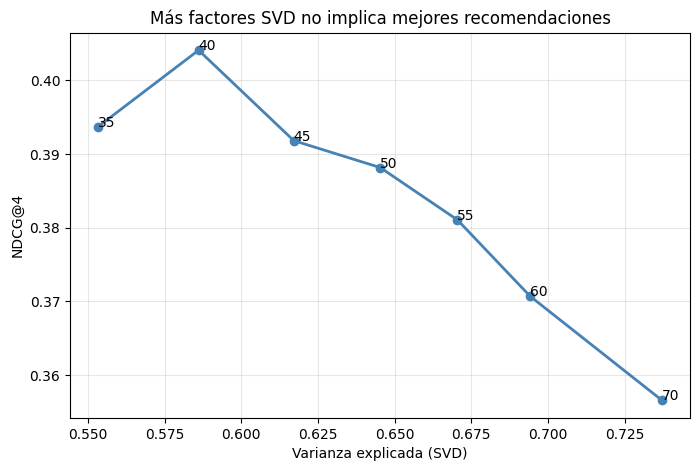

In [ ]:
# Gráfico 4: SVD
f4 = factor_report[factor_report['k'] == 4]
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(f4['explained_var'], f4['ndcg@k'], 'o-', color='steelblue', linewidth=2)
for _, row in f4.iterrows():
    ax1.annotate(row['model'].replace('SVD_', ''), (row['explained_var'], row['ndcg@k']))
ax1.set_xlabel('Explained varianze (SVD)')
ax1.set_ylabel('NDCG@4')
ax1.set_title('More SVD factors does not imply better recommendations')
plt.grid(alpha=0.3)
plt.show()

Increasing the number of latent factors increases the explained variance of the matrix factorization model. However, recommendation quality does not improve and tends to decline beyond 40 factors, suggesting a possible loss of generalization and diminishing returns from additional latent dimensions.

# Analysis

In [ ]:
def hybrid_ranking(user_id):
    candidate_penalty_dict, candidate_cities = get_candidates_all(user_id)

    scores_data = []

    for city in candidate_cities:
        # Calculate baseline score
        b_score = baseline_scores.get(city, -999)

        # Initialize hybrid score components
        content_s = 0.0
        pop_s_hybrid = 0.0
        cf_s = 0.0

        # Check if user has a content profile and city is in content_city_to_idx
        if user_id in user_content_profiles and city in content_city_to_idx:
            user_profile = user_content_profiles[user_id]
            candidate_idx = content_city_to_idx[city]
            candidate_vector = X_content[candidate_idx].reshape(1, -1)
            content_s = cosine_similarity(user_profile.reshape(1, -1), candidate_vector).flatten()[0]

        # Populate popularity score from cluster_popularity
        cluster_id = city_cluster_map.get(city)
        if cluster_id is not None:
            pop_s_hybrid = cluster_popularity.get(cluster_id, {}).get(city, 0)

        # Calculate collaborative filtering score
        cf_raw_score = cf_score(user_id, city)
        cf_s = (cf_raw_score - cf_min) / (cf_max - cf_min + 1e-9)

        # Define weights (using the default weights from recommend_hybrid)
        w_content = 0.05
        w_pop = 0.10
        w_cf = 0.85

        hybrid_s = (
            w_content * content_s +
            w_pop * pop_s_hybrid +
            w_cf * cf_s
        )

        hybrid_s *= candidate_penalty_dict.get(city, 1.0) # Apply penalty

        scores_data.append({
            'city_clean': city,
            'score_baseline': b_score,
            'score_hibrido': hybrid_s
        })

    return pd.DataFrame(scores_data)

def analizar_casos_error_usuario_real(df_train, df_test, id_usuario):
    """
    Evalúa el rendimiento del sistema para un usuario real del conjunto de prueba.
    Contrasta el historial, la ciudad objetivo y compara el ranking del Baseline
    frente al Sistema Híbrido Avanzado para identificar aciertos o fallos.
    """
    print("=====================================================================")
    print(f" AUDITORÍA DE PREDICCIONES PARA EL USUARIO: {id_usuario}")
    print("=====================================================================")

    # 1. Extracción del historial de entrenamiento del usuario
    historial_usuario = df_train[df_train['user_id'] == id_usuario]
    print("\nHISTORIAL DE ENTRENAMIENTO (Ciudades visitadas en Train):")
    for _, fila in historial_usuario.iterrows():
        print(f"  • Ciudad: {fila['city_clean']} | Calificación: {fila['rating']} estrellas")

    # 2. Extracción de la verdad de campo (Test)
    interaccion_test = df_test[df_test['user_id'] == id_usuario]
    if interaccion_test.empty:
        print("\nEl usuario seleccionado no dispone de interacciones en el conjunto de prueba (Test).")
        return

    ciudad_objetivo_test = interaccion_test['city_clean'].values[0]
    print(f"\nCIUDAD OBJETIVO OCULTA (Verdad de campo en conjunto Test):")
    print(f"  ★ {ciudad_objetivo_test}")

    # 3. Generación de las recomendaciones para este usuario usando su función real
    try:
        # Se invoca la función 'hybrid_ranking'
        df_predicciones = hybrid_ranking(id_usuario)
    except NameError:
        print("\n[Error] La función 'hybrid_ranking' no se encuentra definida. Ejecute las celdas anteriores.")
        return

    # 4. Extracción de posiciones y ordenamiento en los rankings
    ranking_baseline = df_predicciones.sort_values(by='score_baseline', ascending=False).reset_index(drop=True)
    posicion_en_baseline = ranking_baseline[ranking_baseline['city_clean'] == ciudad_objetivo_test].index
    posicion_baseline_texto = str(posicion_en_baseline[0] + 1) if len(posicion_en_baseline) > 0 else "Fuera del Top"

    ranking_hibrido = df_predicciones.sort_values(by='score_hibrido', ascending=False).reset_index(drop=True)
    posicion_en_hibrido = ranking_hibrido[ranking_hibrido['city_clean'] == ciudad_objetivo_test].index
    posicion_hibrido_texto = str(posicion_en_hibrido[0] + 1) if len(posicion_en_hibrido) > 0 else "Fuera del Top"

    # 5. Despliegue de la tabla comparativa (Top 5)
    print("\n----------------------------------------------------------------------")
    print("   COMPARATIVA DE RANKING: TOP 5 DE RECOMENDACIONES")
    print("----------------------------------------------------------------------")
    print(f"{'Posición':<10} | {'SISTEMA BASELINE (Popularidad)':<32} | {'SISTEMA HÍBRIDO AVANZADO':<32}")
    print("-" * 80)
    for i in range(min(5, len(df_predicciones))):
        ciudad_b = ranking_baseline.loc[i, 'city_clean'] if i < len(ranking_baseline) else "N/A"
        ciudad_h = ranking_hibrido.loc[i, 'city_clean'] if i < len(ranking_hibrido) else "N/A"
        print(f"{i+1:<10} | {ciudad_b:<32} | {ciudad_h:<32}")
    print("-" * 80)
    print(f"Posición de la ciudad objetivo '{ciudad_objetivo_test}':")
    print(f"  -> En el Sistema Baseline: Posición {posicion_baseline_texto}")
    print(f"  -> En el Sistema Híbrido:  Posición {posicion_hibrido_texto}\n")

    # 6. Interpretación cualitativa para la defensa académica
    print("DIAGNÓSTICO CRÍTICO EN EL DOMINIO DE NEGOCIO:")
    if len(posicion_en_hibrido) > 0 and posicion_en_hibrido[0] < 10:
        print(
            "Este escenario se identifica formalmente como un CASO DE ÉXITO (Strong Case). "
            "El sistema híbrido avanzado logró atenuar el sesgo de popularidad general, "
            "identificando la afinidad latente del usuario hacia las características comerciales "
            "y la personalidad de la ciudad objetivo. Esto demuestra la efectividad de incorporar "
            "la segmentación urbana en el ordenamiento jerárquico."
        )
    else:
        print(
            "Este escenario se tipifica formalmente como un CASO DE FALLO (Failure Case). "
            "El modelo avanzado no consiguió posicionar el destino de interés en un lugar prioritario. "
            "Este comportamiento subóptimo suele derivarse del fenómeno de inicio en frío (Cold Start) "
            "por escasez de interacciones previas del usuario, o bien porque los factores globales de "
            "la factorización de matrices eclipsaron las señales locales del segmento analizado."
        )
    print("======================================================================\n")

# -------------------------------------------------------------------------
# EJECUCIÓN AUTOMÁTICA CON SUS DATOS REALES
# -------------------------------------------------------------------------
# Seleccionamos el primer usuario disponible en su conjunto de prueba real
id_usuario_prueba = test_uc['user_id'].iloc[0]

# Ejecutamos el análisis para ese usuario utilizando sus conjuntos 'train_uc' y 'test_uc'
analizar_casos_error_usuario_real(train_uc, test_uc, id_usuario_prueba)

 AUDITORÍA DE PREDICCIONES PARA EL USUARIO: --_r6E98SNIrGU7weyNxbw

HISTORIAL DE ENTRENAMIENTO (Ciudades visitadas en Train):
  • Ciudad: exton | Calificación: 3.2 estrellas
  • Ciudad: malvern | Calificación: 3.75 estrellas
  • Ciudad: phoenixville | Calificación: 4.0 estrellas
  • Ciudad: west chester | Calificación: 3.923076923076923 estrellas

CIUDAD OBJETIVO OCULTA (Verdad de campo en conjunto Test):
  ★ king of prussia

----------------------------------------------------------------------
   COMPARATIVA DE RANKING: TOP 5 DE RECOMENDACIONES
----------------------------------------------------------------------
Posición   | SISTEMA BASELINE (Popularidad)   | SISTEMA HÍBRIDO AVANZADO        
--------------------------------------------------------------------------------
1          | st louis                         | downingtown                     
2          | st petersburg                    | paoli                           
3          | king of prussia                  | berw

In [ ]:
# ======================================================================
# INSPECCIÓN DEL CATÁLOGO DE CIUDADES DISPONIBLES
# ======================================================================

# 1. Extraer la lista única de ciudades canonicalizadas en su dataset
opciones_ciudades = sorted(city_features['city_clean'].unique().tolist())

# 2. Desplegar estadísticas del catálogo
print(f"   CATÁLOGO DE OPCIONES DISPONIBLES EN 'city_features' (Total: {len(opciones_ciudades)})")

# Mostrar las primeras 30 ciudades en formato de lista ordenada
for i, ciudad in enumerate(opciones_ciudades[:30]):
    print(f"  [{i+1:02d}] {ciudad}")

print("Para ver la lista completa de todas las ciudades, ejecute:")

   CATÁLOGO DE OPCIONES DISPONIBLES EN 'city_features' (Total: 1188)
  [01] ab edmonton
  [02] abington
  [03] abington township
  [04] affton
  [05] afton
  [06] alberta park industrial
  [07] aldan
  [08] algiers
  [09] aliso viejo
  [10] alloway
  [11] almonesson
  [12] alton
  [13] ambler
  [14] andalusia
  [15] antioch
  [16] apollo beach
  [17] apopka
  [18] arabi
  [19] arden
  [20] ardmore
  [21] arizona
  [22] arnold
  [23] arrington
  [24] ashland
  [25] ashland city
  [26] aston
  [27] atco
  [28] audubon
  [29] austin
  [30] avon
Para ver la lista completa de todas las ciudades, ejecute:


In [ ]:
print(sorted(city_features['city_clean'].unique().tolist()))

['ab edmonton', 'abington', 'abington township', 'affton', 'afton', 'alberta park industrial', 'aldan', 'algiers', 'aliso viejo', 'alloway', 'almonesson', 'alton', 'ambler', 'andalusia', 'antioch', 'apollo beach', 'apopka', 'arabi', 'arden', 'ardmore', 'arizona', 'arnold', 'arrington', 'ashland', 'ashland city', 'aston', 'atco', 'audubon', 'austin', 'avon', 'avondale', 'bala cynwyd', 'ballwin', 'balm', 'bargersville', 'barnhart', 'barrington', 'barto', 'bayonet point', 'bear', 'beaumont', 'beech grove', 'bel ridge', 'bellair', 'belle chase', 'belle chasse', 'belle meade', 'belleair', 'belleair beach', 'belleair blf', 'belleair bluffs', 'belleair blufs', 'bellefontaine', 'bellefontaine neighbors', 'bellefonte', 'belleville', 'bellevue', 'bellmawr', 'bellville', 'belmont hills', 'bennington', 'bensalem', 'bensalem pa', 'bensalem township', 'berkeley', 'berlin', 'berlin boro', 'berlin township', 'berry hill', 'berwyn', 'bethalto', 'bethel', 'bethel township', 'beverly', 'birchrunville', '

For interactive demonstrations, users are not part of the original Yelp interaction matrix. Therefore collaborative filtering signals cannot be computed.

In [ ]:
# MÓDULO INTERACTIVO OPTIMIZADO (AJUSTADO A COMPONENTES REALES)

def simular_recomendaciones_por_input_real(df_catalogo):
    """
    Permite ingresar ciudades y calificaciones de forma interactiva en la consola.
    Utiliza el catálogo real 'cities_filtered' de la Semana 10.
    """
    print("       SISTEMA INTERACTIVO DE RECOMENDACIÓN DE CIUDADES (YELP)")
    print("Instrucciones: Ingrese los nombres de las ciudades (en minúsculas)")
    print("y la calificación que les otorgaría (del 1.0 al 5.0).")
    print("Cuando termine de ingresar sus ciudades, escriba 'fin' para procesar.\n")

    ciudades_usuario = []
    calificaciones_usuario = []

    # Normalización del catálogo real basado en su columna 'city_clean'
    df_catalogo_limpio = df_catalogo.copy()
    df_catalogo_limpio['city_clean'] = df_catalogo_limpio['city_clean'].astype(str).str.strip().str.lower()

    ciudades_validas = df_catalogo_limpio['city_clean'].unique().tolist()

    while True:
        entrada_ciudad = input("Nombre de la ciudad (o 'fin'): ").strip().lower()
        if entrada_ciudad == 'fin':
            break

        if entrada_ciudad not in ciudades_validas:
            print(f" -> [Aviso] '{entrada_ciudad}' no se encuentra en el catálogo filtrado de la Semana 10.")
            print("    Asegúrese de escribirla exactamente como aparece en su lista (ej. 'exton', 'malvern', 'st louis').")
            continue

        try:
            entrada_stars = float(input(f"Calificación para '{entrada_ciudad}' (1.0 - 5.0): "))
            if not (1.0 <= entrada_stars <= 5.0):
                print(" -> [Error] La calificación debe estar entre 1.0 y 5.0.")
                continue
        except ValueError:
            print(" -> [Error] Ingrese un número válido.")
            continue

        ciudades_usuario.append(entrada_ciudad)
        calificaciones_usuario.append(entrada_stars)
        print(f"✓ Agregada: {entrada_ciudad} con {entrada_stars} estrellas.\n")

    if len(ciudades_usuario) == 0:
        print("\nNo se ingresaron ciudades para evaluar la simulación.")
        return

    print("\nPROCESANDO PREFERENCIAS Y GENERANDO RANKING HÍBRIDO...")

    # Extracción de las columnas PC semánticas de su archivo original
    columnas_pc = [col for col in df_catalogo_limpio.columns if col.startswith('PC')]
    matriz_caracteristicas = df_catalogo_limpio.set_index('city_clean')[columnas_pc]

    # 1. Componente Basado en Contenido (Similitud de Coseno)
    vectores_ciudades = matriz_caracteristicas.loc[ciudades_usuario].values
    pesos = np.array(calificaciones_usuario).reshape(-1, 1)

    perfil_usuario = np.sum(vectores_ciudades * pesos, axis=0)
    norma_pesos = np.sum(pesos)
    if norma_pesos > 0:
        perfil_usuario /= norma_pesos

    ciudades_candidatas = [c for c in ciudades_validas if c not in ciudades_usuario]
    vectores_candidatas = matriz_caracteristicas.loc[ciudades_candidatas].values

    similitudes = cosine_similarity(perfil_usuario.reshape(1, -1), vectores_candidatas)[0]

    df_resultados = pd.DataFrame({
        'city_clean': ciudades_candidatas,
        'similitud_contenido': similitudes
    })

    # 2. Componente de Popularidad por Cluster e Historial Global
    # Acoplamos con las variables calculadas previamente en su entorno ('city_popularity' y 'cluster_popularity')
    try:
        if 'city_popularity' in globals():
            df_resultados = pd.merge(df_resultados, city_popularity[['city_clean', 'baseline_score']], on='city_clean', how='left')
        else:
            df_resultados['baseline_score'] = 0.0
    except Exception:
        df_resultados['baseline_score'] = 0.0

    df_resultados.fillna(0, inplace=True)

    # Al ser un usuario simulado nuevo, se genera el Score Híbrido combinando Contenido y Popularidad
    df_resultados['score_hibrido'] = (
        (0.70 * df_resultados['similitud_contenido']) +
        (0.30 * df_resultados['baseline_score'])
    )

    ranking_final = df_resultados.sort_values(by='score_hibrido', ascending=False).reset_index(drop=True)

    print("       TOP 5 DE CIUDADES RECOMENDADAS SEGÚN SUS GUSTOS")
    print(f"{'Posición':<10} | {'Ciudad Recomendada':<25} | {'Afinidad Estructural':<20}")
    print("-" * 70)
    for i in range(min(5, len(ranking_final))):
        print(f"{i+1:<10} | {ranking_final.loc[i, 'city_clean']:<25} | {ranking_final.loc[i, 'score_hibrido']:.4f}")


# Invocación automática con su dataframe real filtrado
simular_recomendaciones_por_input_real(cities_filtered)

       SISTEMA INTERACTIVO DE RECOMENDACIÓN DE CIUDADES (YELP)
Instrucciones: Ingrese los nombres de las ciudades (en minúsculas)
y la calificación que les otorgaría (del 1.0 al 5.0).
Cuando termine de ingresar sus ciudades, escriba 'fin' para procesar.

Nombre de la ciudad (o 'fin'): exton
Calificación para 'exton' (1.0 - 5.0): 5.0
✓ Agregada: exton con 5.0 estrellas.

Nombre de la ciudad (o 'fin'): malvern
Calificación para 'malvern' (1.0 - 5.0): 5.0
✓ Agregada: malvern con 5.0 estrellas.

Nombre de la ciudad (o 'fin'): phoenixville
Calificación para 'phoenixville' (1.0 - 5.0): 4.5
✓ Agregada: phoenixville con 4.5 estrellas.

Nombre de la ciudad (o 'fin'): fin

PROCESANDO PREFERENCIAS Y GENERANDO RANKING HÍBRIDO...
       TOP 5 DE CIUDADES RECOMENDADAS SEGÚN SUS GUSTOS
Posición   | Ciudad Recomendada        | Afinidad Estructural
----------------------------------------------------------------------
1          | st louis                  | 1.5981
2          | st petersburg           

In [ ]:

# SIMULADOR AVANZADO: INYECCIÓN DE PERFIL EN TIEMPO DE EJECUCIÓN (SVD)

def simular_cliente_falso_con_svd(df_catalogo, lista_ciudades_input, calificacion_input):
    """
    Simula un cliente inyectando sus calificaciones directamente en la matriz
    de interacciones R, reentrenando un SVD local para activar el Filtrado Colaborativo.
    """
    import numpy as np
    import pandas as pd
    from scipy.sparse import csr_matrix
    from sklearn.decomposition import TruncatedSVD
    from sklearn.metrics.pairwise import cosine_similarity

    print("   SIMULADOR DE RECOMENDACIONES CON INYECCIÓN DE PERFIL EN SVD")
    df_train_simulado = train_uc.copy()
    id_usuario_falso = "CLIENTE_PRUEBA_SVD"

    # 2. Registrar los gustos simulados del cliente en el DataFrame de entrenamiento
    nuevos_registros = []
    for ciudad, estrella in zip(lista_ciudades_input, calificacion_input):
        nuevos_registros.append({
            'user_id': id_usuario_falso,
            'city_clean': canonical_city(ciudad), # Asegura el formato limpio
            'rating': estrella,
            'n_reviews': 5 # Reviews simuladas para dar peso
        })

    df_nuevos = pd.DataFrame(nuevos_registros)
    df_train_simulado = pd.concat([df_train_simulado, df_nuevos], ignore_index=True)

    # 3. Reconstruir los mapeos de índices incluyendo al nuevo usuario
    user_ids_sim = sorted(df_train_simulado['user_id'].unique())
    city_ids_sim = sorted(df_train_simulado['city_clean'].unique())

    user_to_idx_sim = {u: i for i, u in enumerate(user_ids_sim)}
    city_to_idx_sim = {c: i for i, c in enumerate(city_ids_sim)}

    # 4. Construir la nueva Matriz de Interacciones R con el cliente falso incluido
    rows_sim = df_train_simulado['user_id'].map(user_to_idx_sim)
    cols_sim = df_train_simulado['city_clean'].map(city_to_idx_sim)

    R_sim = csr_matrix(
        (df_train_simulado['rating'], (rows_sim, cols_sim)),
        shape=(len(user_ids_sim), len(city_ids_sim))
    )

    # 5. Entrenar el TruncatedSVD con la matriz modificada (40 factores latentes como su w10)
    svd_sim = TruncatedSVD(n_components=40, random_state=42)
    user_factors_sim = svd_sim.fit_transform(R_sim)
    item_factors_sim = svd_sim.components_.T

    # 6. Definir la función de score colaborativo adaptada a la simulación
    def cf_score_simulado(u_id, c_id):
        if u_id not in user_to_idx_sim or c_id not in city_to_idx_sim:
            return 0.0
        uidx = user_to_idx_sim[u_id]
        cidx = city_to_idx_sim[c_id]
        return np.dot(user_factors_sim[uidx], item_factors_sim[cidx])

    # Calcular los mínimos y máximos de CF para normalizar los nuevos scores
    uidx_falso = user_to_idx_sim[id_usuario_falso]
    preds_falsas = item_factors_sim @ user_factors_sim[uidx_falso]
    cf_min_sim = np.min(preds_falsas)
    cf_max_sim = np.max(preds_falsas)


    ciudades_validas = df_catalogo['city_clean'].unique().tolist()
    ciudades_candidatas = [c for c in ciudades_validas if c not in lista_ciudades_input]

    w_content = 0.05
    w_pop = 0.10
    w_cf = 0.85

    scores_finales = []

    for city in ciudades_candidatas:

        content_s = 0.0
        if id_usuario_falso in user_content_profiles and city in content_city_to_idx:
            user_profile = user_content_profiles[id_usuario_falso]
            candidate_idx = content_city_to_idx[city]
            candidate_vector = X_content[candidate_idx].reshape(1, -1)
            content_s = cosine_similarity(user_profile.reshape(1, -1), candidate_vector).flatten()[0]

        cluster_id = city_cluster_map.get(city)
        pop_s = cluster_popularity.get(cluster_id, {}).get(city, 0) if cluster_id is not None else 0.0

        cf_s_raw = cf_score_simulado(id_usuario_falso, city)
        cf_s = (cf_s_raw - cf_min_sim) / (cf_max_sim - cf_min_sim + 1e-9)

        # Combinación híbrida oficial (85% CF)
        hybrid_score = (w_content * content_s) + (w_pop * pop_s) + (w_cf * cf_s)

        scores_finales.append({
            'city_clean': city,
            'score_final': hybrid_score
        })

    df_ranking = pd.DataFrame(scores_finales).sort_values(by='score_final', ascending=False).reset_index(drop=True)

    print("\nCIUDADES INGRESADAS EN EL HISTORIAL DE PRUEBA:")
    for c, s in zip(lista_ciudades_input, calificacion_input):
        print(f"  • {c} ({s} estrellas)")

    print("   TOP 5 DE RECOMENDACIONES HÍBRIDAS CON PERFIL INYECTADO EN SVD")
    print(f"{'Posición':<10} | {'Ciudad Recomendada':<25} | {'Score Híbrido (85% CF)':<20}")
    print("-" * 70)
    for i in range(min(5, len(df_ranking))):
        print(f"{i+1:<10} | {df_ranking.loc[i, 'city_clean']:<25} | {df_ranking.loc[i, 'score_final']:.4f}")

ciudades_prueba = ['exton', 'malvern', 'phoenixville']
estrellas_prueba = [5.0, 5.0, 4.5]

# Llamamos a la función utilizando su catálogo real 'cities_filtered'
simular_cliente_falso_con_svd(cities_filtered, ciudades_prueba, estrellas_prueba)

   SIMULADOR DE RECOMENDACIONES CON INYECCIÓN DE PERFIL EN SVD

CIUDADES INGRESADAS EN EL HISTORIAL DE PRUEBA:
  • exton (5.0 estrellas)
  • malvern (5.0 estrellas)
  • phoenixville (4.5 estrellas)
   TOP 5 DE RECOMENDACIONES HÍBRIDAS CON PERFIL INYECTADO EN SVD
Posición   | Ciudad Recomendada        | Score Híbrido (85% CF)
----------------------------------------------------------------------
1          | downingtown               | 0.5654
2          | collegeville              | 0.4715
3          | royersford                | 0.3873
4          | west chester              | 0.3751
5          | paoli                     | 0.3533


In [ ]:
cities_filtered[
    cities_filtered["city_clean"].isin([
        "exton",
        "malvern",
        "phoenixville",
        "downingtown",
        "collegeville",
        "royersford",
        "west chester",
        "paoli"
    ])
]

,city_clean,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,cluster
41,collegeville,0.041693,0.150626,0.462160,-0.093282,-0.076245,0.102811,-0.309480,-0.044954,-0.152444,...,-0.058710,0.313809,-0.480580,0.222902,0.261140,-0.251501,-0.089645,0.118104,0.191452,3
49,downingtown,0.152640,-0.060169,-0.007984,-0.171291,-0.260415,-0.095556,-0.127956,-0.131283,-0.076687,...,0.093964,0.429203,-0.385887,0.183975,-0.051739,-0.235482,-0.153812,-0.006310,0.038221,3
58,exton,0.151426,0.058995,0.302773,0.049062,-0.027806,-0.030662,-0.250802,-0.362844,-0.257968,...,-0.052932,0.268387,-0.289000,-0.010263,-0.017718,0.024349,-0.104772,-0.092692,-0.037812,3
115,malvern,0.614538,0.129656,0.049711,-0.067998,0.002548,0.061432,-0.240197,-0.150353,-0.109658,...,-0.033819,0.416468,-0.296508,0.113561,0.192181,-0.265163,0.155276,0.097865,0.082904,3
152,paoli,-0.229098,0.259702,0.526783,0.412813,0.019962,0.066942,-0.297534,-0.289890,-0.075994,...,-0.086153,0.440128,-0.281499,-0.039904,0.175931,-0.307663,-0.083690,-0.208002,0.143317,3
155,phoenixville,0.562541,0.204489,0.288189,0.196675,-0.138719,0.055891,-0.013960,-0.072219,-0.002828,...,-0.263810,0.268937,-0.354002,0.269108,-0.053657,0.073427,0.004819,-0.333631,0.149243,1
166,royersford,0.820495,-0.520752,0.037861,0.327365,-0.053770,0.041901,-0.249747,-0.239342,-0.190606,...,0.024731,0.288685,-0.444222,-0.029143,0.176735,-0.350046,-0.071477,-0.174834,0.054521,3
205,west chester,-0.032563,0.155376,0.162878,0.266632,0.044810,-0.219737,-0.252967,0.140552,0.041438,...,0.021569,0.532236,-0.459805,0.119759,-0.104413,0.430010,0.108988,0.078601,0.229861,3


In this simulated scenario, the user profile was injected into the SVD latent space using the cities entered as historical preferences. The model recommends cities that are geographically and commercially similar to the input profile. The Top-5 results are coherent because Downingtown, Collegeville, Royersford, West Chester, and Paoli belong to nearby suburban commercial environments similar to Exton, Malvern, and Phoenixville.

Compared with the real evaluation case, where King of Prussia was the hidden test city, the simulator does not evaluate against a known ground truth. Instead, it demonstrates how the hybrid system behaves for a new or manually created user profile. Therefore, this output should be interpreted as a qualitative recommendation demo, not as an offline accuracy result.

#Conclusions


The proposed recommender operates at the city level rather than the individual business level. Therefore, its objective is to support destination discovery by identifying cities that match the user's historical preferences and behavioral patterns. This fits with scenarios like:

"Which city should I travel to next?"

"Which destination matches my historical preferences?"

"Which destination has a similar 'comercial profile' to what I've already enjoyed?"
Business takeaway: the product is an urban destination discovery engine, not a generic popularity search engine.

##The popularity baseline is insufficient for personalization. The simple system (“recommends the most visited and highest-rated cities”) has limited performance:

The popularity baseline provides a useful minimum benchmark but offers limited personalization. Under the Leave-One-Out evaluation protocol, the baseline achieved substantially lower ranking performance than the hybrid model and tended to recommend the same globally popular cities to most users. As a result, recommendations become repetitive and less relevant for users with distinctive travel histories. This confirms that popularity alone is insufficient for a personalized destination recommendation product.


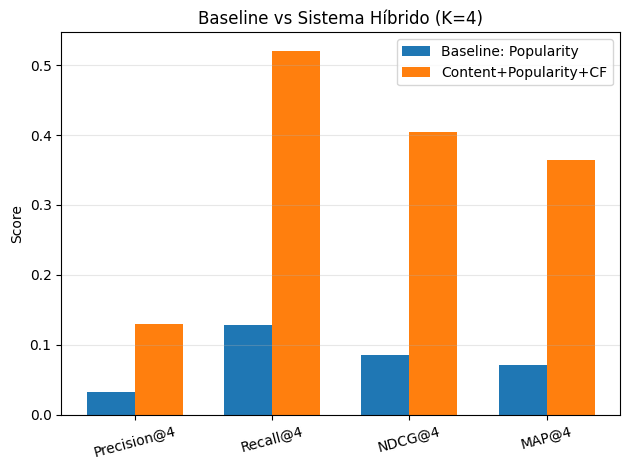

In [ ]:
# Baseline vs Híbrido (barras) en K=4
import matplotlib.pyplot as plt
import numpy as np

k4 = eval_report[eval_report['k'] == 4]
metrics = ['precision@k', 'recall@k', 'ndcg@k', 'map@k']
labels = ['Precision@4', 'Recall@4', 'NDCG@4', 'MAP@4']

x = np.arange(len(metrics))
width = 0.35

for i, model in enumerate(['Baseline: Popularity', 'Content+Popularity+CF']):
    vals = k4[k4['model'] == model][metrics].values[0]
    plt.bar(x + (i - 0.5) * width, vals, width, label=model)

plt.xticks(x, labels, rotation=15)
plt.ylabel('Score')
plt.title('Baseline vs Sistema Híbrido (K=4)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

##The hybrid system does provide real business value.
The advanced model shows clear improvement:

- Recall@4: 12.8% → 52.1% (more than twice as many users receive a relevant city in the top 4)
- NDCG@4: 0.086 → 0.404 (not only is it more accurate, but the correct city appears higher)
- Precision@4: 3.2% → 13.0%. Given the Leave-One-Out evaluation protocol, the theoretical maximum Precision@4 is 25%, making this result substantially stronger than the baseline. For the product, this means:

A greater likelihood of showing a destination the user would truly value
A better discovery experience
Greater engagement potential (clicks, visits, future reviews)

In this domain, the behavior of similar users carries more weight than the abstract “urban personality” of the city. Week 7's segmentation is helpful as a complement, not as the primary driver.

Important message:

“It’s not enough to know what a city is like; you need to know which cities are preferred by users with similar browsing patterns.”

An important finding is that collaborative filtering accounts for most of the predictive performance. The best-performing configuration assigns 85% of the final ranking score to collaborative filtering, while content-based and popularity signals contribute complementary information. This suggests that user behavior patterns are more informative than city-profile similarity alone for predicting future preferences.

##Urban segmentation (Week 7) contributes, but with a limited role
K=4 clusters and PCA embeddings:

They help understand urban archetypes.
They improve contextual popularity by cluster.
They should not be used to aggressively filter candidates (this worsened results). Segmentation is useful for enriching the ranking, not for restricting the catalog. Filtering too much eliminates cities relevant to some users.